In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Synthetic data (replace with real data if needed)
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_clusters_per_class=1,
                           class_sep=1.5, random_state=0)

print("First 5 samples:")
print(X[:5])
print("Labels:", y[:5])

First 5 samples:
[[ 1.57033369 -0.42915356]
 [-0.97565612  1.77888341]
 [ 1.38590571  2.1901946 ]
 [ 1.86581799  1.57715301]
 [-1.7607126   1.3950888 ]]
Labels: [1 0 1 1 0]


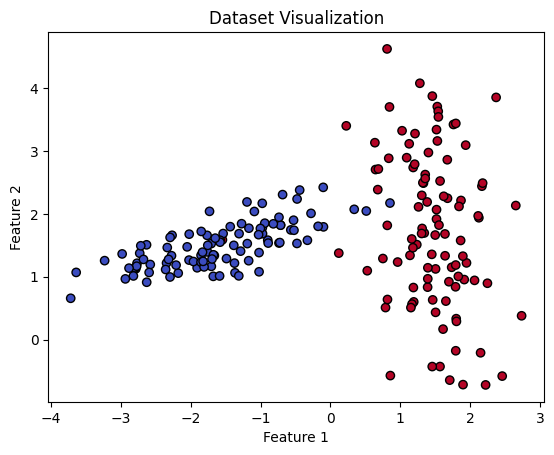

In [2]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Dataset Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", C=1.0, gamma="scale")
model.fit(X, y)

print("Training accuracy:", model.score(X, y))

Training accuracy: 0.975


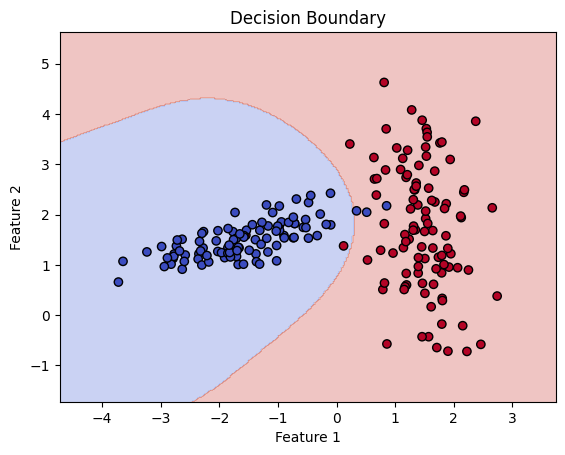

In [4]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

model2 = SVC(kernel="rbf", C=1.0, gamma="scale")
model2.fit(X_train, y_train)

print("Train accuracy:", model2.score(X_train, y_train))
print("Test accuracy:", model2.score(X_test, y_test))

Train accuracy: 0.9714285714285714
Test accuracy: 1.0


## Q2 Summary of Results

In this task, we generated a synthetic 2‑class dataset, visualized it, trained an RBF‑kernel SVM, and evaluated its performance. The dataset forms two clearly separable clusters. The SVM model achieves high performance, with a training accuracy of **0.975**. The decision boundary plot shows that the classifier successfully separates the two classes with a smooth nonlinear boundary. When evaluated using a train/test split, the model achieves **0.9714** training accuracy and **1.0** test accuracy, indicating good generalization without signs of overfitting.